# Organization Score (Lag-Rank)

> Condense temporal organization into a single scalar per subject.

The organization score measures temporal organization by computing, for each transition, the percentile rank of the actual absolute lag among all available absolute lags. A score of 0.5 indicates chance; scores above 0.5 reflect a temporal contiguity effect. Unlike Lag-CRP curves, the lag-rank score produces a single per-subject scalar that can be tested against chance with a one-sample $t$-test.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.lagrank import plot_lagrank
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
yticks = None
trial_query = "data['listLength'] > 0"
size = 1
color_cycle = None
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

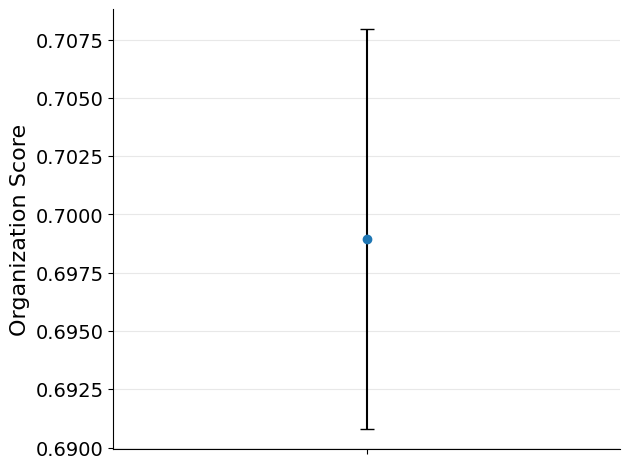

In [4]:
plot_lagrank(
    data,
    trial_mask,
    size=size,
    color_cycle=color_cycle,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
if yticks is not None:
    for ax in plt.gcf().axes:
        ax.set_yticks(yticks)
save_figure(figure_dir, figure_str)

## Interpretation

The plot shows the mean per-subject temporal factor score with bootstrap confidence intervals.

- **Scores above 0.5**: temporal contiguity — transitions favor nearby study positions.
- **Scores near 0.5**: chance-level temporal organization.
- **Scores below 0.5**: anti-contiguity (rare in typical free recall).

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits for the point plot, or `None` for automatic scaling.
- `yticks` — y-axis ticks for the point plot, or `None` for automatic ticks.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `size` — maximum number of study positions a single item can occupy (1 for no-repeat lists).
- `color_cycle` — point colors, or `None` for the default cycle. For list-type plots, use `["#2ca02c", "#ff4d4d", "#4da3df"]`.
- `confidence_level` — confidence level for subject-wise error bars.